# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor:Jose Manuel Tenchipe del Valle

Grado y grupo: 9B

Maestra: Maria Reina Zarate Nava

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ventas-por-factura.csv')

In [7]:
df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [11]:
dfCopy = df.copy()
dfCopy.shape

(25953, 6)

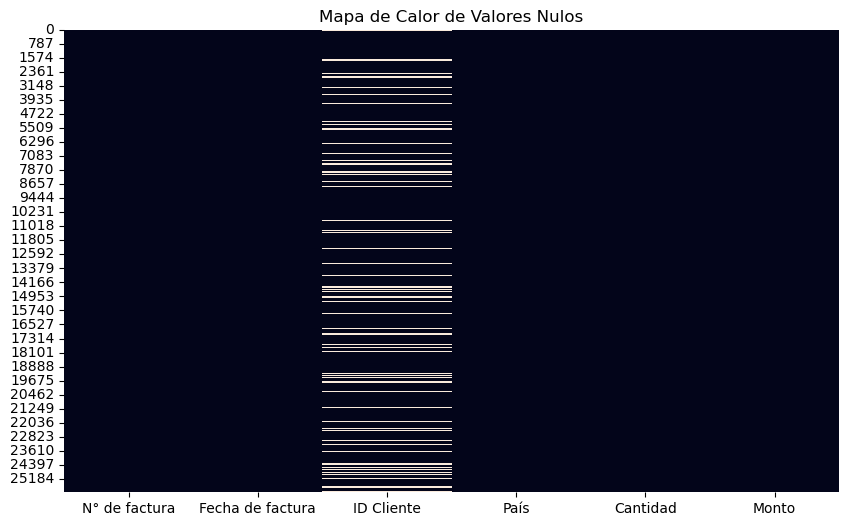

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Mapa de Calor de Valores Nulos')
plt.show()

In [23]:
df['Monto'] = df['Monto'].astype(str).str.replace(',', '.').astype(float)
df['Monto']

0         229.33
1         209.73
2          -1.45
3          39.95
4         344.83
          ...   
25948     -12.70
25949     720.00
25950     298.78
25951    1488.00
25952       0.00
Name: Monto, Length: 25943, dtype: float64

In [22]:
df['Fecha de factura'] = pd.to_datetime(df['Fecha de factura'])
df['Fecha de factura'].dt.year

0        2021
1        2021
2        2021
3        2021
4        2021
         ... 
25948    2021
25949    2021
25950    2021
25951    2021
25952    2020
Name: Fecha de factura, Length: 25943, dtype: int32

In [14]:
duplicados = df.duplicated().sum()
duplicados

np.int64(10)

In [15]:
df = df.drop_duplicates()
duplicados = df.duplicated().sum()
duplicados

np.int64(0)

In [17]:
facturas_canceladas = df[df['N° de factura'].astype(str).str.startswith('C')]
facturas_canceladas

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,2021-10-12 11:32:00,12471.0,Germany,-1,-1.45
10,C543628,2021-02-10 15:51:00,16558.0,United Kingdom,-5,-9.25
17,C553508,2021-05-17 13:44:00,14000.0,United Kingdom,-3,-1.95
20,C577693,2021-11-21 11:48:00,12628.0,Germany,-3,-16.85
22,C547309,2021-03-22 11:17:00,17416.0,United Kingdom,-12,-45.00
...,...,...,...,...,...,...
25939,C572450,2021-10-24 12:35:00,NaN,United Kingdom,-2,-278.15
25943,C557061,2021-06-16 14:55:00,14895.0,United Kingdom,-5,-14.75
25944,C562147,2021-08-03 10:47:00,16180.0,United Kingdom,-7,-18.35
25947,C553519,2021-05-17 14:16:00,18218.0,United Kingdom,-2,-9.90


In [24]:
#opte por quedarme con una copia del dataset original pero con ventas reales (sin las que tengan la C, que son las canceladas)
df_limpio = df[~df['N° de factura'].astype(str).str.startswith('C')].copy()

In [26]:
df_limpio = df_limpio[(df_limpio['Cantidad'] > 0) & (df_limpio['Monto'] > 0)]
df_limpio

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,2021-03-30 16:14:00,15528.0,United Kingdom,123,229.33
1,575767,2021-11-11 11:11:00,17348.0,United Kingdom,163,209.73
3,549106,2021-04-06 12:08:00,17045.0,United Kingdom,1,39.95
4,573112,2021-10-27 15:33:00,16416.0,United Kingdom,357,344.83
5,576630,2021-11-16 08:38:00,13816.0,Germany,91,199.98
...,...,...,...,...,...,...
25945,579252,2021-11-28 16:47:00,17450.0,United Kingdom,432,1034.40
25946,574908,2021-11-07 15:37:00,16009.0,United Kingdom,28,82.76
25949,553060,2021-05-13 10:44:00,15826.0,United Kingdom,488,720.00
25950,577049,2021-11-17 13:58:00,17397.0,United Kingdom,104,298.78


In [30]:
df_limpio.isnull().sum()

N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
dtype: int64

In [29]:
df_limpio['ID Cliente'] = df_limpio['ID Cliente'].fillna(0).astype(int)
df_limpio['País'] = df_limpio['País'].fillna('Unspecified')
df_limpio.isnull().sum()

N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
dtype: int64

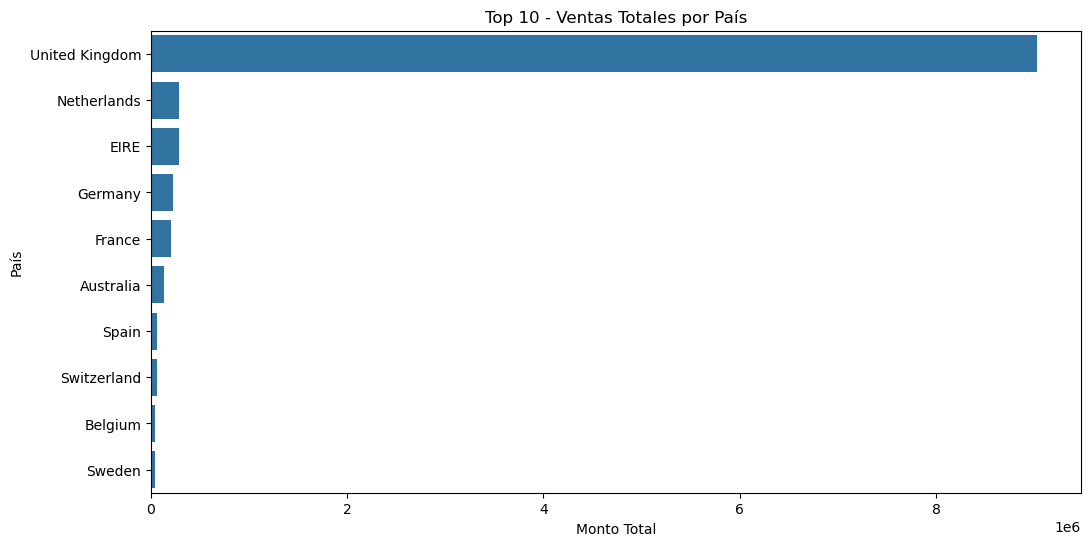

In [33]:
plt.figure(figsize=(12, 6))
ventas_pais = df_limpio.groupby('País')['Monto'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=ventas_pais.values, y=ventas_pais.index)
plt.title('Top 10 - Ventas Totales por País')
plt.xlabel('Monto Total')
plt.ylabel('País')
plt.show()

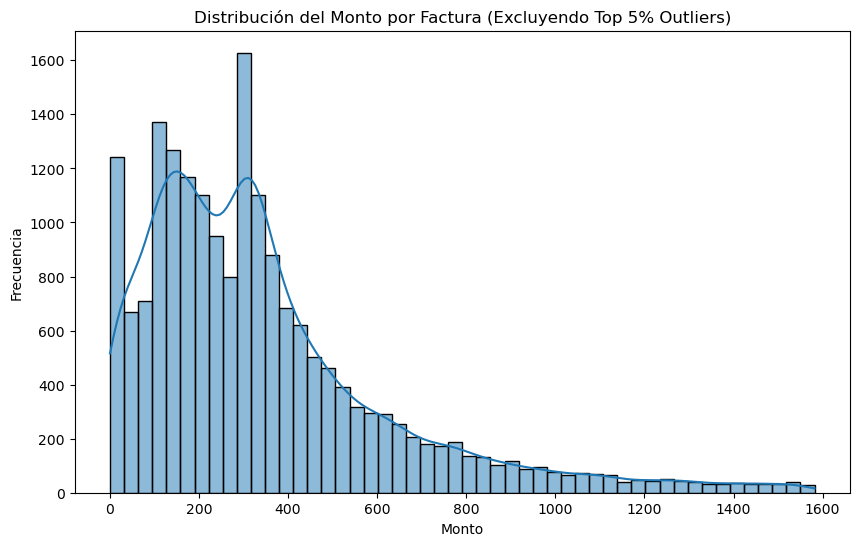

In [36]:
# estoy imprimiendo la distribucion del monto con base a la recurrencia, ademas ocupo el percentil 95 para sacar el techo de los datos
# que estan en el 95% y evitar los segos visuales y naturales de los datos 
plt.figure(figsize=(10, 6))
limite_superior = df_limpio['Monto'].quantile(0.95)
datos_dist = df_limpio[df_limpio['Monto'] <= limite_superior]
sns.histplot(datos_dist['Monto'], bins=50, kde=True)
plt.title('Distribución del Monto por Factura (Excluyendo Top 5% Outliers)')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.show()

### Justificación de la Limpieza y Transformación

* **Corrección de formato numérico:** Remplace las comas por puntos en los montos, ya que los algoritmos no pueden procesar texto asi que es mejor pasar a punto en lugar de coma ademas de que requieren valores numéricos reales por eso la necesidad de pasarlos a (`float`).
* **Filtrado de facturas canceladas y negativos:** Las facturas (identificadas con 'C' o montos negativos) se separan porque afectan a las metricas de los ingresos efectivos o reales, ademas de que creo que para tener otra vision se debe de analizar el dataset de cancelaciones aparte, para optener otros datos con base a las cancelaciones.
* **Imputación de valores nulos:** no quise eliminar las filas sin `ID Cliente` en lugar de eliminar las filas sin `ID Cliente` (lo que borraría ventas e ingresos reales), las rrellene con un valor genérico (`0`), con esto busco preservar el balance total financiero, para no afectar a modelos de segmentacion, que se pueden ocupar en un futuro.

---

### El Principio GIGO (*Garbage In, Garbage Out*)

**Impacto resumido:**

1. **En el Análisis de Datos (BI):** Los datos sucios (como sumar devoluciones como si fueran ventas) generan métricas falsas. Esto lleva a que se tomen decisiones de negocio basadas en una realidad equivocada.
2. **En Machine Learning:** Los algoritmos aprenden de los patrones que les damos. Si introducimos "basura" (outliers extremos, formatos inválidos, valores nulos sin tratar), el modelo aprenderá reglas falsas, produciendo predicciones contaminadas o segmentaciones completamente inservibles, como se dijo, si se introduce basura recibes basura.